In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
pip install mlflow scikit-learn pandas numpy matplotlib seaborn 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 83.8 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 92.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 14.3 MB/s eta 0:00:00
Note: you may need to restart 

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic equipment data
n_samples = 10000

# Features
temperature = np.random.normal(75, 15, n_samples)  # °C
vibration = np.random.normal(0.5, 0.2, n_samples)  # mm/s
pressure = np.random.normal(100, 20, n_samples)  # PSI
rpm = np.random.normal(1500, 200, n_samples)  # RPM
age_days = np.random.randint(0, 365, n_samples)  # Days since last maintenance

# Create failure condition (combination of factors)
failure_score = (
    (temperature > 90) * 0.3
    + (vibration > 0.8) * 0.3
    + (pressure > 130) * 0.2
    + (age_days > 300) * 0.2
)

# Add some randomness
failure_prob = failure_score + np.random.normal(0, 0.1, n_samples)
failure = (failure_prob > 0.5).astype(int)

# Create DataFrame
data = pd.DataFrame(
    {
        "temperature": temperature,
        "vibration": vibration,
        "pressure": pressure,
        "rpm": rpm,
        "age_days": age_days,
        "failure": failure,
    }
)

# Output dataset summary
print(f"Dataset shape: {data.shape}")
print(f"Failure rate: {data.failure.mean():.2%}")
print("\nFirst 5 rows of the dataset:")
print(data.head())

Dataset shape: (10000, 6)
Failure rate: 4.15%

First 5 rows of the dataset:
   temperature  vibration    pressure          rpm  age_days  failure
0    82.450712   0.364301  106.965725  1103.885606       187        0
1    72.926035   0.438900  105.666472  1289.002871       239        0
2    84.715328   0.380524   81.269603  1382.594319         2        0
3    97.845448   0.522084  111.591684  1529.933782         5        0
4    71.487699   0.739436   70.198346  1704.832465       259        0



Summary Statistics:
        temperature     vibration      pressure           rpm      age_days  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      74.967960      0.502707     99.750745   1498.485705    181.908000   
std       15.051936      0.200202     19.828363    200.897414    105.568632   
min       16.163996     -0.271275     26.898270    606.879227      0.000000   
25%       64.911142      0.367598     85.996962   1361.077430     90.000000   
50%       74.961075      0.503169     99.884635   1497.923551    182.000000   
75%       85.066213      0.638773    113.277949   1635.806091    272.000000   
max      133.893566      1.395817    173.832490   2245.566669    364.000000   

            failure  
count  10000.000000  
mean       0.041500  
std        0.199454  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  

Missing values:
temperature    0
vibration      0
pressure       0
r

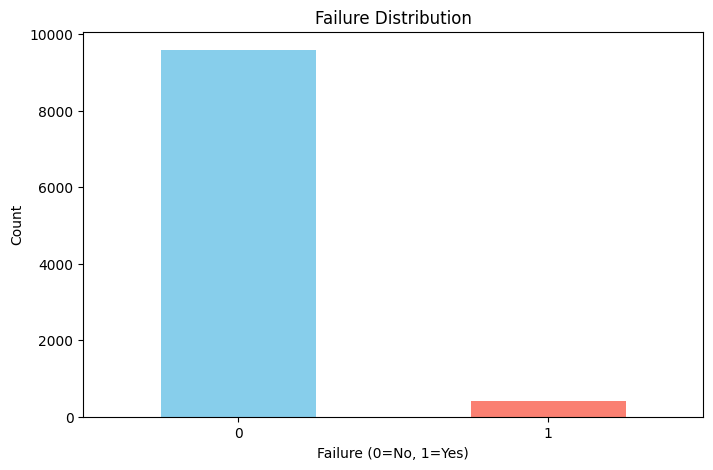

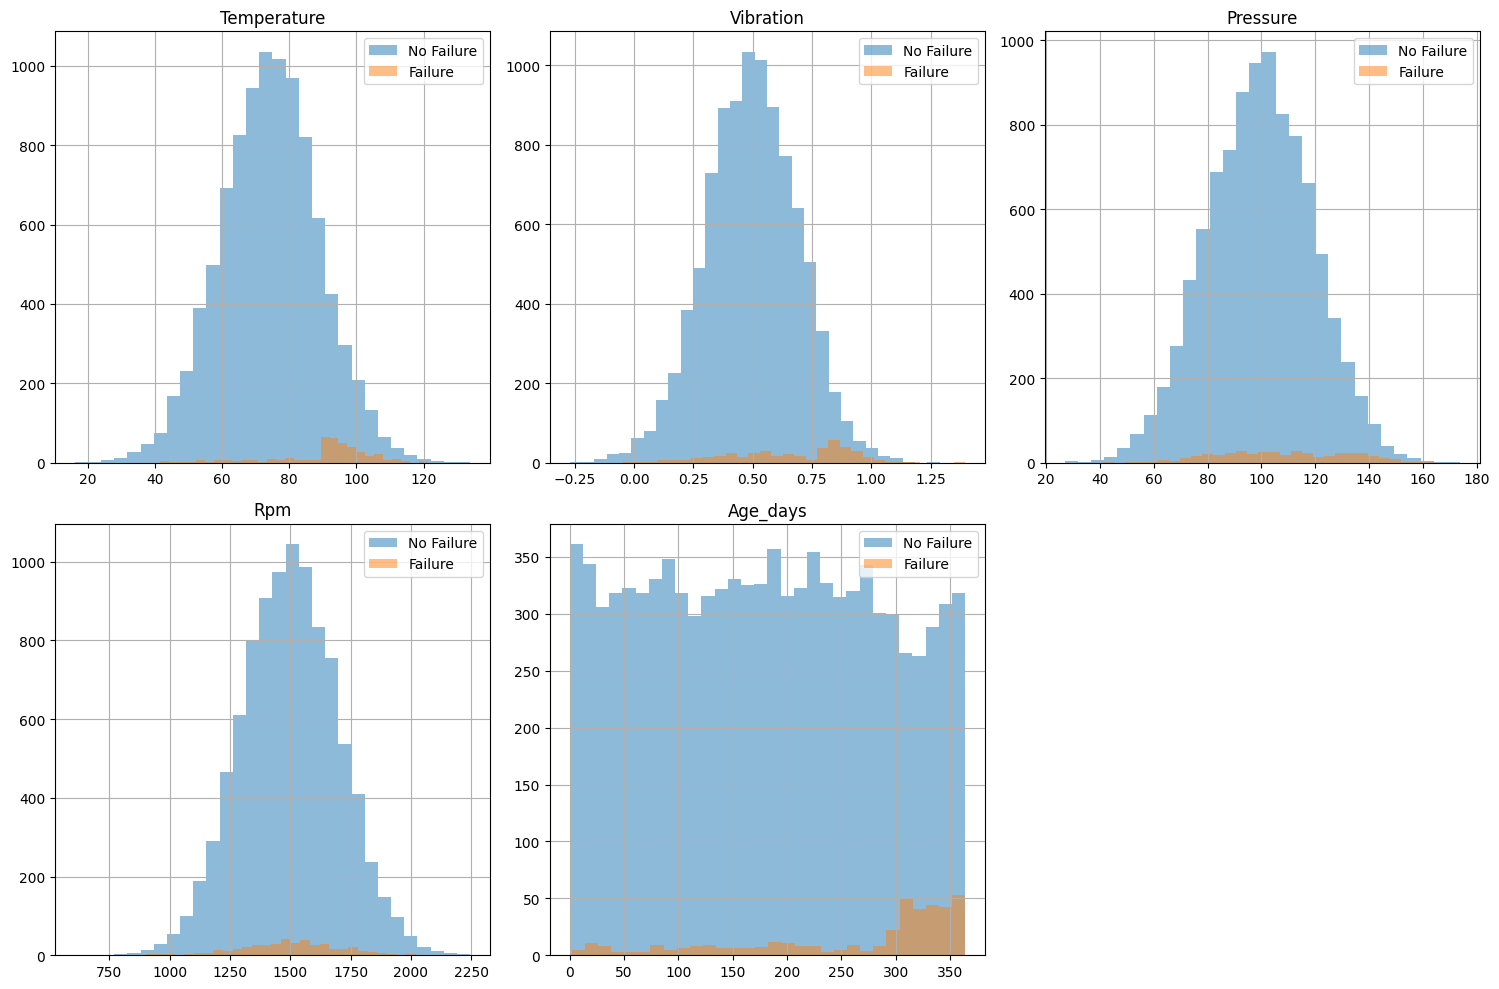

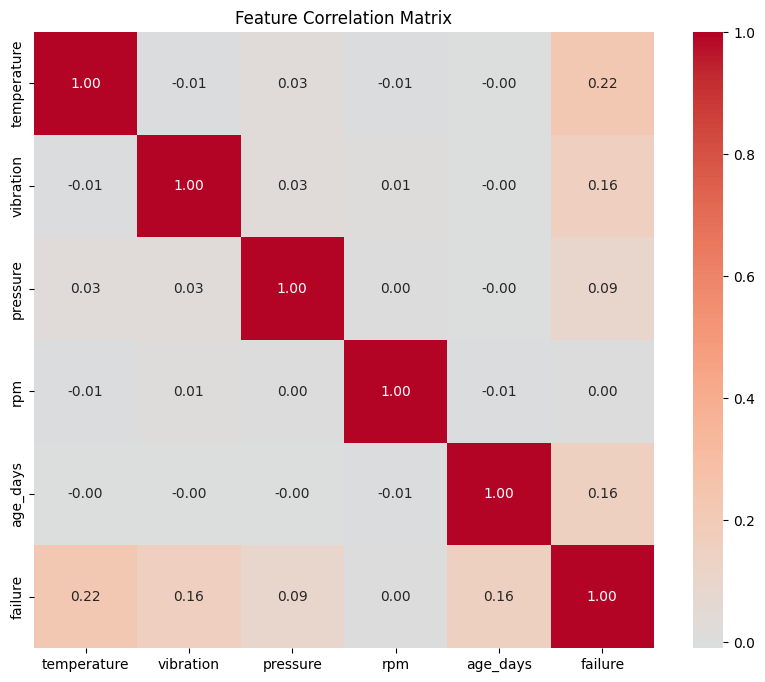

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics
print("\nSummary Statistics:")
print(data.describe())

# Check for missing values
print("\nMissing values:")
print(data.isnull().sum())

# Class distribution
plt.figure(figsize=(8, 5))
data["failure"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Failure Distribution")
plt.xlabel("Failure (0=No, 1=Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)  # Keeps the '0' and '1' labels upright
plt.show()

# Feature distributions by class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ["temperature", "vibration", "pressure", "rpm", "age_days"]

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    data[data.failure == 0][feature].hist(
        ax=ax, alpha=0.5, label="No Failure", bins=30
    )
    data[data.failure == 1][feature].hist(
        ax=ax, alpha=0.5, label="Failure", bins=30
    )
    ax.set_title(feature.capitalize())
    ax.legend()

# Turn off the empty 6th subplot (row 1, col 2) to keep the layout clean
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

## Part 2: MLflow Setup

In [7]:
# 1. Install required packages in Kaggle
!pip install mlflow scikit-learn pandas numpy matplotlib seaborn xgboost --quiet

# 2. Start the MLflow UI server in the background inside Kaggle
import subprocess
import time

print("Starting MLflow background server inside Kaggle...")
subprocess.Popen(
    ["mlflow", "ui", "--host", "127.0.0.1", "--port", "5000"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

# Wait 3 seconds for the server to initialize
time.sleep(3)
print("MLflow server is successfully running locally inside Kaggle!")

Starting MLflow background server inside Kaggle...
MLflow server is successfully running locally inside Kaggle!


### Task 2.1: Start MLflow Tracking Server

In [8]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("predictive-maintenance")

2026/06/07 07:44:46 INFO mlflow.tracking.fluent: Experiment with name 'predictive-maintenance' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1780818286405, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780818286405, lifecycle_stage='active', name='predictive-maintenance', tags={}, trace_location=None, workspace='default'>

### Task 2.3: Prepare Data for Training

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split features and target
X = data.drop("failure", axis=1)
y = data["failure"]

# Train/test split with stratification to preserve baseline failure rates
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train failure rate: {y_train.mean():.2%}")
print(f"Test failure rate: {y_test.mean():.2%}")

Training set: (8000, 5)
Test set: (2000, 5)
Train failure rate: 4.15%
Test failure rate: 4.15%


## Part 3: Model Training & Tracking

### Task 3.1: Train Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

C = 1.0
max_iter = 1000

# Start MLflow run
with mlflow.start_run(run_name="logistic_regression"):
    # Log parameters
    mlflow.log_param("C", C)
    mlflow.log_param("max_iter", max_iter)
    mlflow.log_param("model_type", "LogisticRegression")

    # Train model
    model = LogisticRegression(C=C, max_iter=max_iter, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log model artifact
    mlflow.sklearn.log_model(model, "model")

    print("Logistic Regression Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")

2026/06/07 07:47:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 07:47:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression Results:
Accuracy:  0.9620
Precision: 0.6842
Recall:    0.1566
F1 Score:  0.2549
ROC AUC:   0.9234
🏃 View run logistic_regression at: http://127.0.0.1:5000/#/experiments/1/runs/f3b7f64f3db14feebad7eca45008ff64
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


### Task 3.2: Train Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

n_estimators = 100
max_depth = 10
min_samples_split = 5

with mlflow.start_run(run_name="random_forest"):
    # Log parameters
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("min_samples_split", min_samples_split)
    mlflow.log_param("model_type", "RandomForest")

    # Train model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
    )
    model.fit(X_train_scaled, y_train)

    # Evaluate
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log model artifact
    mlflow.sklearn.log_model(model, "model")

    print("\nRandom Forest Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")

2026/06/07 07:48:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 07:48:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Random Forest Results:
Accuracy:  0.9670
Precision: 0.6049
Recall:    0.5904
F1 Score:  0.5976
ROC AUC:   0.9751
🏃 View run random_forest at: http://127.0.0.1:5000/#/experiments/1/runs/d6215e92386e41e8a824245de14f40d9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


### Task 3.3: Train XGBoost

In [12]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [13]:
from xgboost import XGBClassifier

n_estimators = 100
max_depth = 6
learning_rate = 0.1

with mlflow.start_run(run_name="xgboost"):
    # Log parameters
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("model_type", "XGBoost")

    # Train model
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42,
        eval_metric="logloss",
    )
    model.fit(X_train_scaled, y_train)

    # Evaluate
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log model artifact
    mlflow.sklearn.log_model(model, "model")

    print("\nXGBoost Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")

2026/06/07 07:48:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 07:48:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



XGBoost Results:
Accuracy:  0.9670
Precision: 0.6076
Recall:    0.5783
F1 Score:  0.5926
ROC AUC:   0.9709
🏃 View run xgboost at: http://127.0.0.1:5000/#/experiments/1/runs/f5549889db754a4e8ec774d3ab7d4f63
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
